# Artificial Intelligence & Deep Learning - Group project notebook


### Group members
|Name| UID|
|----|----|
|Jacob Davies|(2248087)|
|QIAN TANG|(5759707) |
|YEFENG WANG|(5744925)|
|RAGUL PALANISAMY|(5759086)|
|ROHAN BAGUL|(5744267)|
|ELIE YENE |(5749933)|


### Data - Heart Disease dataset

This dataset contains clinical measurements used to predict the presence of heart disease.

The version used in machine learning research is the **Cleveland Heart Disease dataset**, which is part of the larger UCI Heart Disease database.

Although the full database contains 76 attributes, we will use a subset of 14 key attributes.

These attributes include:

- demographic data
- clinical test results
- exercise measurements
- cardiovascular indicators

The target variable indicates whether the patient has heart disease.

Values range from:

- 0 → no disease
- 1–4 → presence of disease

For classification we will simplify:

- 0 → No Heart Disease
- 1 → Heart Disease Present

### AI disclosure

AI was used to assist with specific tasks such as explaining errors and finding bugs. 
Any AI-generated content used has been criticly evauated and modified.


In [1]:
import pandas as pd
import numpy as np
import torch as th

import matplotlib.pyplot as plt


/Users/jacob/Downloads/easy-diffusion/installer_files/env/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Import the Cleveland Heart Disease dataset
- from dataprofessor's `data` github repo
- then load it `df` as a pandas data frame

In [2]:
url = "https://raw.githubusercontent.com/dataprofessor/data/master/heart-disease-cleveland.csv"

In [3]:
df = pd.read_csv(url)

### validate data

In [4]:
# Check for missing values
# df.isnull().sum() -- retunrs all 0s
df.eq("?").sum()

age           0
 sex          0
 cp           0
 trestbps     0
 chol         0
 fbs          0
 restecg      0
 thalach      0
 exang        0
 oldpeak      0
 slope        0
 ca           4
 thal         2
 diagnosis    0
dtype: int64

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': ' sex'}>,
        <Axes: title={'center': ' cp'}>],
       [<Axes: title={'center': ' trestbps'}>,
        <Axes: title={'center': ' chol'}>,
        <Axes: title={'center': ' fbs'}>],
       [<Axes: title={'center': ' restecg'}>,
        <Axes: title={'center': ' thalach'}>,
        <Axes: title={'center': ' exang'}>],
       [<Axes: title={'center': ' oldpeak'}>,
        <Axes: title={'center': ' slope'}>,
        <Axes: title={'center': ' diagnosis'}>]], dtype=object)

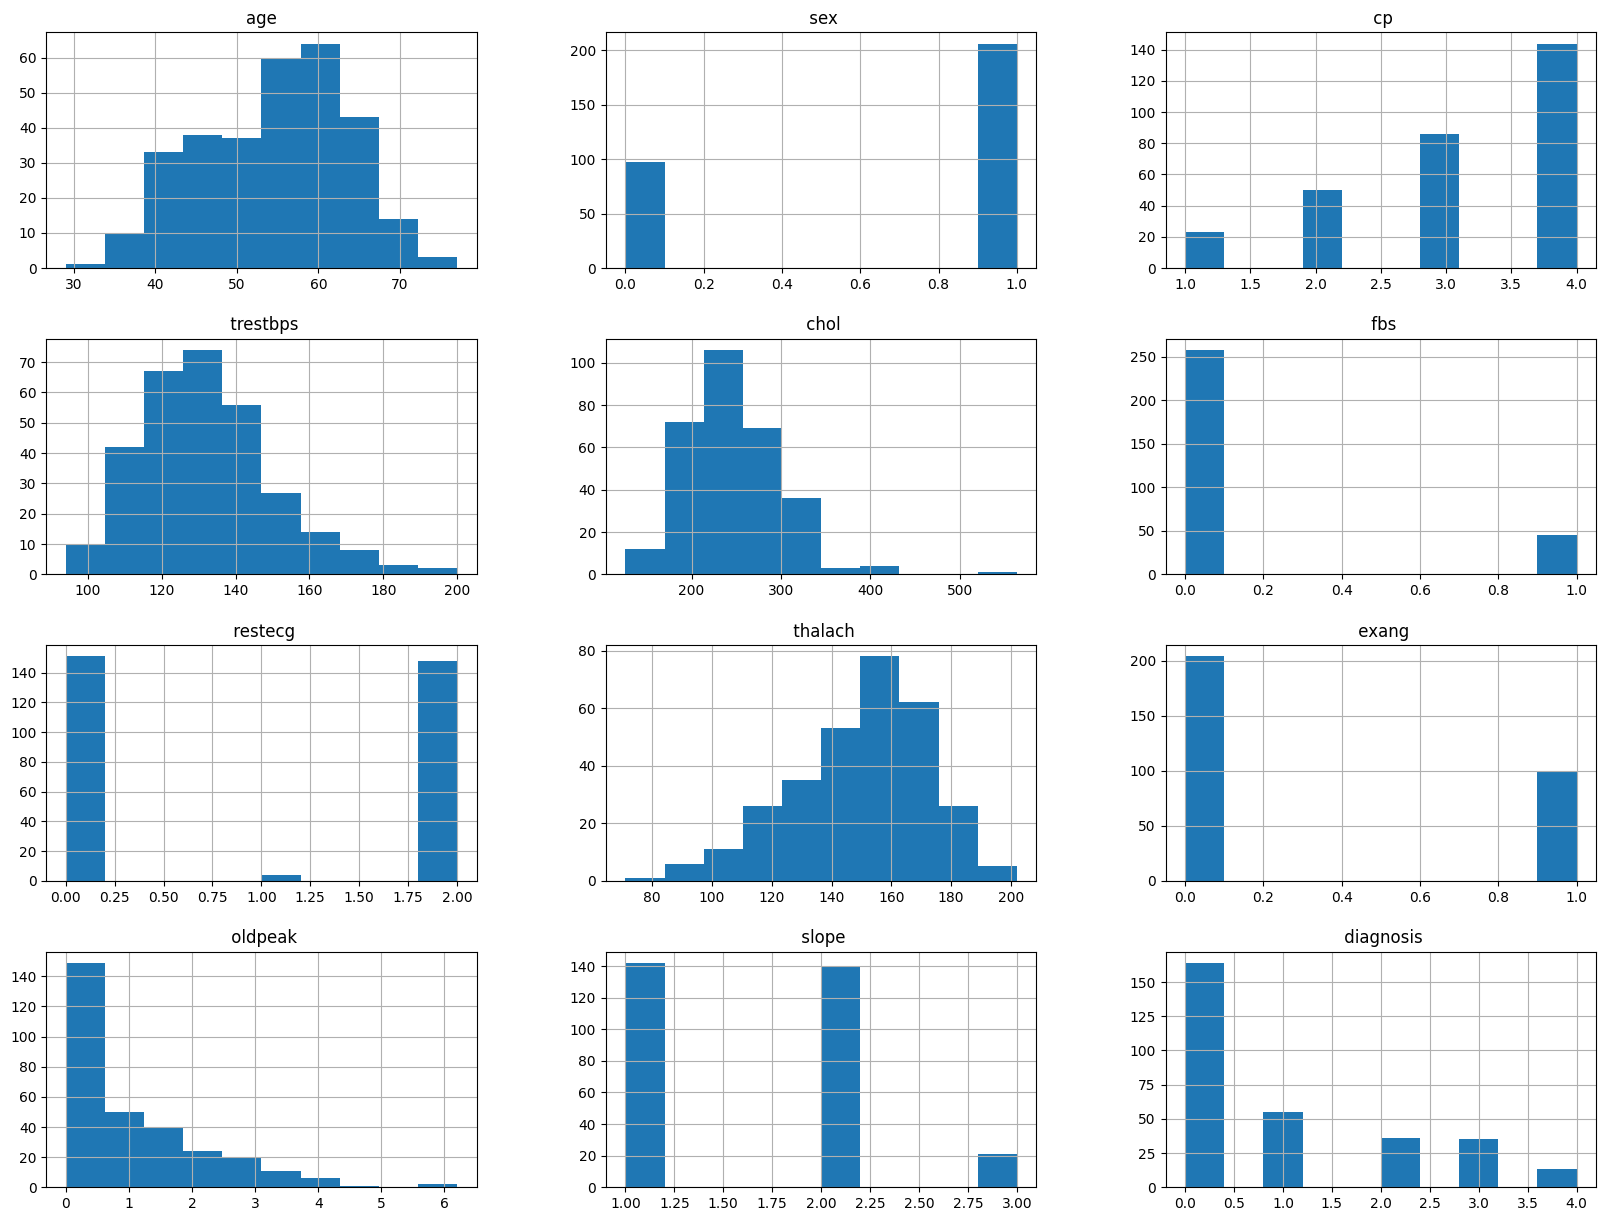

In [5]:
# Analyze the distributions of varables to look for outlyers
df.hist(bins=10, figsize=(20, 15))

### Pre processing 
- Drop `?` entrys
- Diagnosis 0-4 → 0-1
- Balence output column

In [6]:
# Drop rows with missing values ("?")
df = df.replace("?", np.nan).dropna()

In [7]:
# All columns have leading spaces, so we need to strip them
df.columns = df.columns.str.strip()

In [8]:
# Diagnosis becomes binary classification problem (0 = no heart disease, 1 = heart disease)
df["diagnosis"] = df["diagnosis"].apply(lambda x: 1 if x > 0 else 0)

<Axes: >

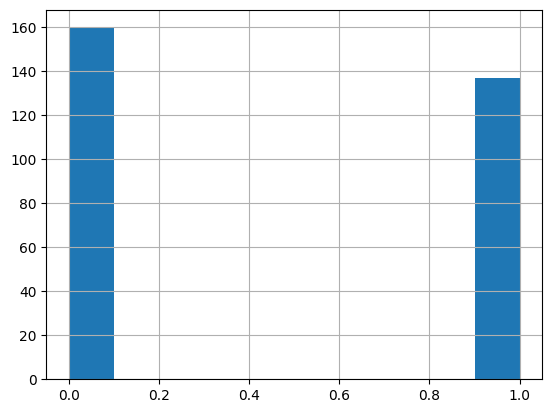

In [9]:
df["diagnosis"].hist()

### Balence data

In [ ]:
# drop data 

### Seperate Train test split

In [10]:
train_val, test = np.split(df.sample(frac=1, random_state=42), [int(0.8 * len(df))])
train, val = np.split(train_val.sample(frac=1, random_state=42), [int(0.8 * len(train_val))])